# AI Bot Traffic in DataCite DOI Resolutions

**Question 1 — How much of DOI-resolution traffic comes from AI tools?**
**Question 2 — What is the pattern of *non-successful* resolutions?** A failed
resolution (Handle response code `100`, `RC_HANDLE_NOT_FOUND`) means the
requested DOI **does not exist** — a direct signal of a hallucinated or
mistyped DOI.

**Data:** `datacite.resolution_logs` in Amazon Athena (one row per resolution
event, partitioned by year/month/region). Months available: **Apr–Jul 2026**.

## Two independent AI signals

AI traffic is identified from **both** available fields — they capture different
populations that barely overlap:

| Signal | Field | Who it is |
|---|---|---|
| **AI referral (web UI)** | `referrer_url` (`chatgpt.com`, `perplexity.ai`, …) | a **human** followed a link from an AI tool's interface |
| **AI crawler (user-agent)** | `user_agent` (`GPTBot`, `ClaudeBot`, `Bytespider`, …) | an **automated agent** fetched the DOI directly |

A resolution is counted as AI if **either** signal fires. Even together these are
a **lower bound** — agents that spoof a browser user-agent and strip the referrer
are invisible.

> **One crawler dominates, so it gets its own bucket.** Liner (`LinerBot`,
> getliner.com) is ~19% of *all* DataCite resolution traffic across these four
> months — but it **crawled aggressively then shut off**: ~37% of April traffic,
> tapering to essentially zero by July. Lumped into "AI crawler" it would mask
> everything else, so it is broken out as its own category — **Liner**, **AI
> crawler (ex-Liner)**, **AI referral (web UI)**, **Non-AI**.

DataCite DOIs resolve through the **Handle System**: `1 = RC_SUCCESS`,
`100 = RC_HANDLE_NOT_FOUND`. "Not-found rate" = share of events with code `100`.

## Setup

In [1]:
# In Google Colab, install the dependencies first:
import sys
if "google.colab" in sys.modules:
    !pip install -q pyathena python-dotenv pandas matplotlib

In [2]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import Patch

plt.rcParams.update({
    "figure.dpi": 120, "font.family": "sans-serif",
    "axes.edgecolor": "#c3c2b7", "axes.labelcolor": "#0b0b0b", "text.color": "#0b0b0b",
    "xtick.color": "#52514e", "ytick.color": "#52514e",
    "axes.grid": True, "grid.color": "#e1e0d9", "grid.linewidth": 0.8,
    "axes.axisbelow": True,   # gridlines behind bars/markers, not over them
    "axes.spines.top": False, "axes.spines.right": False,
})
BLUE, GREEN, AMBER, RED, GRAY, INK = "#2a78d6", "#1baf7a", "#eda100", "#e34948", "#898781", "#0b0b0b"
C_REF, C_UA, C_LINER, C_BASE = RED, BLUE, AMBER, GRAY   # referral / crawler(ex-Liner) / Liner / baseline

MONTH_NAMES = {1:"Jan",2:"Feb",3:"Mar",4:"Apr",5:"May",6:"Jun",
               7:"Jul",8:"Aug",9:"Sep",10:"Oct",11:"Nov",12:"Dec"}

# --- Signal 1: AI referral, matched on referrer_url (one pattern -> tool) ---
REF_TOOLS = [
    ("chatgpt.com","ChatGPT"), ("perplexity.ai","Perplexity"),
    ("gemini.google.com","Gemini"), ("claude.ai","Claude"),
    ("copilot.microsoft.com","Copilot"), ("scispace.com","SciSpace"),
    ("consensus.app","Consensus"), ("elicit.com","Elicit"),
    ("researchrabbit.ai","ResearchRabbit"), ("doubao.com","Doubao"),
    ("bohrium.com","Bohrium"), ("you.com","You.com"),
    ("phind.com","Phind"), ("poe.com","Poe"),
]
REF_CASE = ("CASE " + " ".join(
    f"WHEN referrer_url LIKE '%{d}%' THEN '{n}'" for d, n in REF_TOOLS
) + " ELSE 'Non-AI' END")

# --- Signal 2: AI crawler, matched on user_agent (list of tokens -> company) ---
UA_BOTS = [
    (["gptbot","oai-searchbot","chatgpt-user"], "OpenAI"),
    (["claudebot","claude-web","claude-user","anthropic"], "Anthropic"),
    (["perplexity"], "Perplexity"),
    (["linerbot"], "Liner"),
    (["bytespider"], "Bytespider"),
    (["ccbot"], "CommonCrawl"),
    (["google-extended"], "Google-Extended"),
    (["amazonbot"], "Amazon"),
    (["meta-externalagent","facebookbot"], "Meta"),
    (["cohere"], "Cohere"),
    (["youbot"], "You.com"),
    (["applebot-extended"], "Apple"),
]
UA_CASE = ("CASE " + " ".join(
    "WHEN " + " OR ".join(f"lower(user_agent) LIKE '%{p}%'" for p in pats) + f" THEN '{n}'"
    for pats, n in UA_BOTS
) + " ELSE 'Non-AI' END")

### Load the data

One Athena scan classifies every event by **both** signals at once
(`ref_tool` from the referrer, `ua_bot` from the user-agent) and by outcome.
All downstream metrics are derived from this single aggregate; if Athena
credentials aren't present it falls back to the cached `ai_bot_agg2.csv`.

In [3]:
CSV_CACHE = Path("ai_bot_agg2.csv")
AGG_SQL = (
    "SELECT year, month, " + REF_CASE + " AS ref_tool, " + UA_CASE + " AS ua_bot,\n"
    "       count(*) AS total,\n"
    "       count_if(response_code = 1)   AS success,\n"
    "       count_if(response_code = 100) AS not_found\n"
    "FROM datacite.resolution_logs\n"
    "GROUP BY year, month, " + REF_CASE + ", " + UA_CASE + "\n"
    "ORDER BY year, month"
)

def load_from_athena():
    from dotenv import load_dotenv
    from pyathena import connect
    for cand in (Path.cwd()/".env", Path.cwd().parent/".env"):
        if cand.exists():
            load_dotenv(cand); break
    conn = connect(
        aws_access_key_id=os.environ["DEST_AWS_ACCESS_KEY_ID"],
        aws_secret_access_key=os.environ["DEST_AWS_SECRET_ACCESS_KEY"],
        s3_staging_dir="s3://datacite-logs-processed/athena-results/",
        region_name="us-east-2",
    )
    return pd.read_sql(AGG_SQL, conn)

try:
    df = load_from_athena()
    df.to_csv(CSV_CACHE, index=False)
    print(f"Loaded {len(df)} rows from Athena (cached to {CSV_CACHE}).")
except Exception as e:
    print(f"Athena unavailable ({type(e).__name__}); loading cached {CSV_CACHE}.")
    df = pd.read_csv(CSV_CACHE)

df["label"] = df["month"].map(MONTH_NAMES)
df["ref_ai"] = df["ref_tool"] != "Non-AI"       # human via AI web UI
df["ua_ai"] = df["ua_bot"] != "Non-AI"          # any automated AI crawler
df["is_liner"] = df["ua_bot"] == "Liner"        # the one mega-crawler, broken out
df["ua_exl"] = df["ua_ai"] & ~df["is_liner"]    # crawlers EXCLUDING Liner
df["is_ai"] = df["ref_ai"] | df["ua_ai"]
# Per-row event / not-found contributions, per category (for clean group-sums).
for flag, tag in [("ref_ai","ref"), ("ua_ai","ua"), ("ua_exl","exl"),
                  ("is_liner","liner"), ("is_ai","ai"), (None,"non")]:
    m = ~df["is_ai"] if flag is None else df[flag]
    df[f"{tag}_ev"] = df["total"].where(m, 0)
    df[f"{tag}_nf"] = df["not_found"].where(m, 0)
MONTHS = [MONTH_NAMES[m] for m in sorted(df["month"].unique())]
df.head()

/var/folders/j3/ztw0mlmd4kxcgk2tbrkqp2gm0000gn/T/ipykernel_8767/4090321398.py:24: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(AGG_SQL, conn)


Loaded 114 rows from Athena (cached to ai_bot_agg2.csv).


,year,month,ref_tool,ua_bot,total,success,not_found,label,ref_ai,ua_ai,...,ua_ev,ua_nf,exl_ev,exl_nf,liner_ev,liner_nf,ai_ev,ai_nf,non_ev,non_nf
0,2026,4,Doubao,Non-AI,7299,5973,1326,Apr,True,False,...,0,0,0,0,0,0,7299,1326,0,0
1,2026,4,ResearchRabbit,Non-AI,6539,6507,32,Apr,True,False,...,0,0,0,0,0,0,6539,32,0,0
2,2026,4,SciSpace,Non-AI,19891,19845,46,Apr,True,False,...,0,0,0,0,0,0,19891,46,0,0
3,2026,4,Non-AI,CommonCrawl,10284,10097,187,Apr,False,True,...,10284,187,10284,187,0,0,10284,187,0,0
4,2026,4,Non-AI,Amazon,288204,273341,14861,Apr,False,True,...,288204,14861,288204,14861,0,0,288204,14861,0,0


## Part 1 — AI share of resolution traffic (both signals)

Combining the referrer and user-agent signals, what fraction of resolutions is
AI-driven — and how does it split between human referrals and automated crawlers?

In [4]:
def rate(mask):
    s = df[mask]; t = int(s["total"].sum()); nf = int(s["not_found"].sum())
    return t, nf, (100*nf/t if t else 0.0)

tot = int(df["total"].sum())
ai_t, ai_nf, ai_r = rate(df.is_ai)
ref_t, ref_nf, ref_r = rate(df.ref_ai)
liner_t, liner_nf, liner_r = rate(df.is_liner)
exl_t, exl_nf, exl_r = rate(df.ua_exl)
non_t, non_nf, non_r = rate(~df.is_ai)
print(f"Total resolutions (Apr–Jul 2026): {tot:,}")
print(f"AI combined            : {ai_t:,}  ({100*ai_t/tot:.3f}% of all traffic)")
print(f"  - Liner (LinerBot)   : {liner_t:,}  ({100*liner_t/tot:.3f}%)")
print(f"  - AI crawler ex-Liner: {exl_t:,}  ({100*exl_t/tot:.3f}%)")
print(f"  - AI referral (web UI): {ref_t:,}  ({100*ref_t/tot:.4f}%)")
print(f"AI excluding Liner     : {ai_t-liner_t:,}  ({100*(ai_t-liner_t)/tot:.3f}%)")
print(f"Non-AI                 : {non_t:,}")

bm = (df.groupby(["month","label"], as_index=False)
        .agg(total=("total","sum"), liner=("liner_ev","sum"),
             exl=("exl_ev","sum"), ref=("ref_ev","sum")))
for c in ("liner","exl","ref"):
    bm[f"{c}_pct"] = 100*bm[c]/bm["total"]
bm = bm.sort_values("month")
bm[["label","total","liner_pct","exl_pct","ref_pct"]]

Total resolutions (Apr–Jul 2026): 1,690,524,311
AI combined            : 337,786,331  (19.981% of all traffic)
  - Liner (LinerBot)   : 323,374,053  (19.129%)
  - AI crawler ex-Liner: 13,922,868  (0.824%)
  - AI referral (web UI): 490,130  (0.0290%)
AI excluding Liner     : 14,412,278  (0.853%)
Non-AI                 : 1,352,737,980


,label,total,liner_pct,exl_pct,ref_pct
0,Apr,634600821,36.971869,0.538183,0.025043
1,May,445233913,17.697423,0.678691,0.034501
2,Jun,320705918,3.103904,1.256357,0.026497
3,Jul,289983659,0.000322,1.191992,0.031939


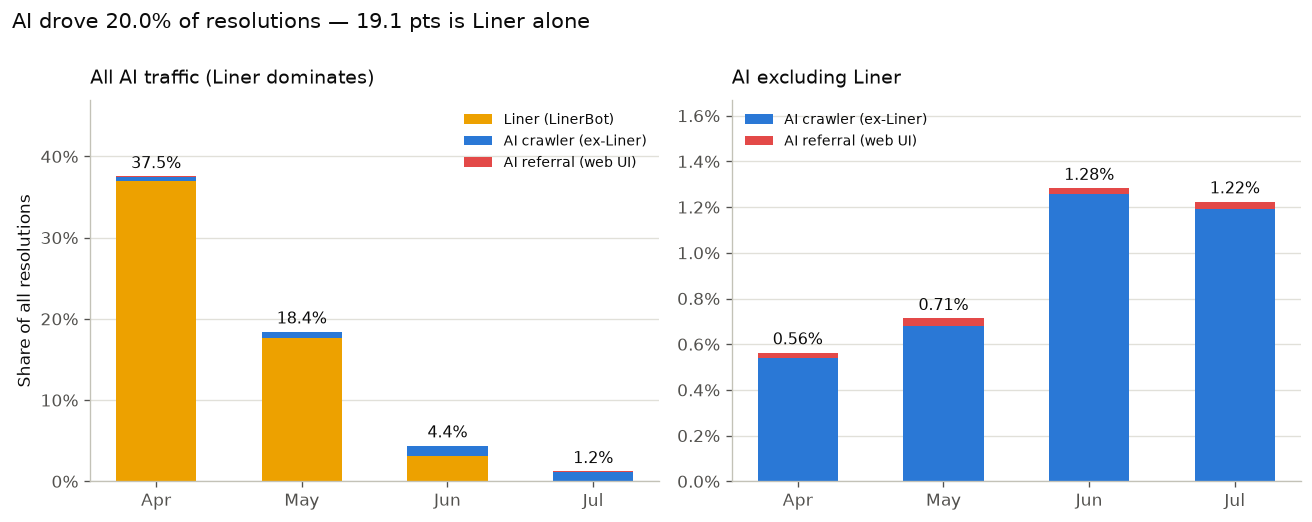

In [5]:
# Liner dwarfs the rest, so show two panels sharing the month axis: total AI
# share (Liner-dominated) on the left, and AI-excluding-Liner (readable) right.
fig, (axL, axR) = plt.subplots(1, 2, figsize=(11, 4.3))
x = np.arange(len(bm))
segs = [("liner_pct", C_LINER, "Liner (LinerBot)"),
        ("exl_pct", C_UA, "AI crawler (ex-Liner)"),
        ("ref_pct", C_REF, "AI referral (web UI)")]

bottom = np.zeros(len(bm))
for col, color, lab in segs:
    axL.bar(x, bm[col], width=0.55, bottom=bottom, color=color, label=lab)
    bottom += bm[col].values
for xi, tot_pct in zip(x, bottom):
    axL.annotate(f"{tot_pct:.1f}%", (xi, tot_pct), textcoords="offset points",
                 xytext=(0,5), ha="center", fontsize=9.5, color=INK)
axL.set_xticks(x); axL.set_xticklabels(bm["label"]); axL.set_ylabel("Share of all resolutions")
axL.set_ylim(0, bottom.max()*1.25)
axL.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))
axL.set_title("All AI traffic (Liner dominates)", loc="left", fontsize=11.5, pad=10)
axL.grid(axis="x", visible=False); axL.legend(frameon=False, fontsize=8.5, loc="upper right")

bottom = np.zeros(len(bm))
for col, color, lab in segs[1:]:   # ex-Liner only
    axR.bar(x, bm[col], width=0.55, bottom=bottom, color=color, label=lab)
    bottom += bm[col].values
for xi, tot_pct in zip(x, bottom):
    axR.annotate(f"{tot_pct:.2f}%", (xi, tot_pct), textcoords="offset points",
                 xytext=(0,5), ha="center", fontsize=9.5, color=INK)
axR.set_xticks(x); axR.set_xticklabels(bm["label"])
axR.set_ylim(0, bottom.max()*1.30)
axR.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f%%"))
axR.set_title("AI excluding Liner", loc="left", fontsize=11.5, pad=10)
axR.grid(axis="x", visible=False); axR.legend(frameon=False, fontsize=8.5, loc="upper left")

fig.suptitle(f"AI drove {100*ai_t/tot:.1f}% of resolutions — {100*liner_t/tot:.1f} pts is Liner alone",
             x=0.01, ha="left", fontsize=12.5, y=1.0)
fig.tight_layout(); plt.show()

## Part 2 — Non-successful resolutions by signal

The two AI populations should fail differently: a **human** following a
hallucinated DOI from a chat UI is a stronger error signal than a **crawler**
systematically fetching (mostly real) DOIs.

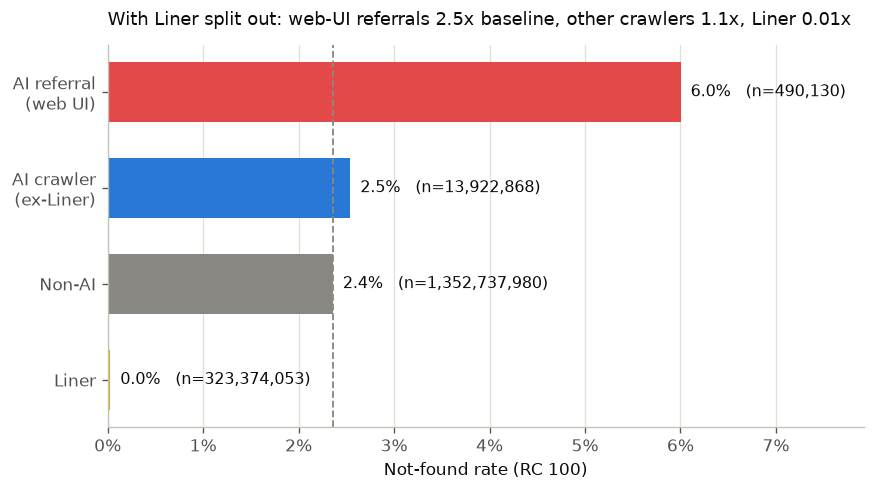

,cat,total,not_found,nf_rate
0,Liner,323374053,89907,0.027803
1,Non-AI,1352737980,31914568,2.359257
2,AI crawler\n(ex-Liner),13922868,353916,2.541976
3,AI referral\n(web UI),490130,29419,6.002285


In [6]:
cats = [("Liner", df.is_liner, C_LINER),
        ("Non-AI", ~df.is_ai, C_BASE),
        ("AI crawler\n(ex-Liner)", df.ua_exl, C_UA),
        ("AI referral\n(web UI)", df.ref_ai, C_REF)]
rows = [(name, *rate(mask), color) for name, mask, color in cats]
cat_df = pd.DataFrame(rows, columns=["cat","total","not_found","nf_rate","color"]).sort_values("nf_rate")

fig, ax = plt.subplots(figsize=(7.4, 4.2))
bars = ax.barh(cat_df["cat"], cat_df["nf_rate"], color=cat_df["color"], height=0.62)
for bar, r, t in zip(bars, cat_df["nf_rate"], cat_df["total"]):
    ax.annotate(f"{r:.1f}%   (n={t:,})", (bar.get_width(), bar.get_y()+bar.get_height()/2),
                textcoords="offset points", xytext=(6,0), va="center", fontsize=9.5, color=INK)
ax.axvline(non_r, color=C_BASE, lw=1.1, ls="--", zorder=1)
ax.set_xlabel("Not-found rate (RC 100)")
ax.set_xlim(0, cat_df["nf_rate"].max()*1.32)
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))
ax.set_title(f"With Liner split out: web-UI referrals {ref_r/non_r:.1f}x baseline, "
             f"other crawlers {exl_r/non_r:.1f}x, Liner {liner_r/non_r:.2f}x",
             loc="left", fontsize=11.0, pad=12)
ax.grid(axis="y", visible=False)
fig.tight_layout(); plt.show()
cat_df[["cat","total","not_found","nf_rate"]]

### Not-found rate by month, per signal

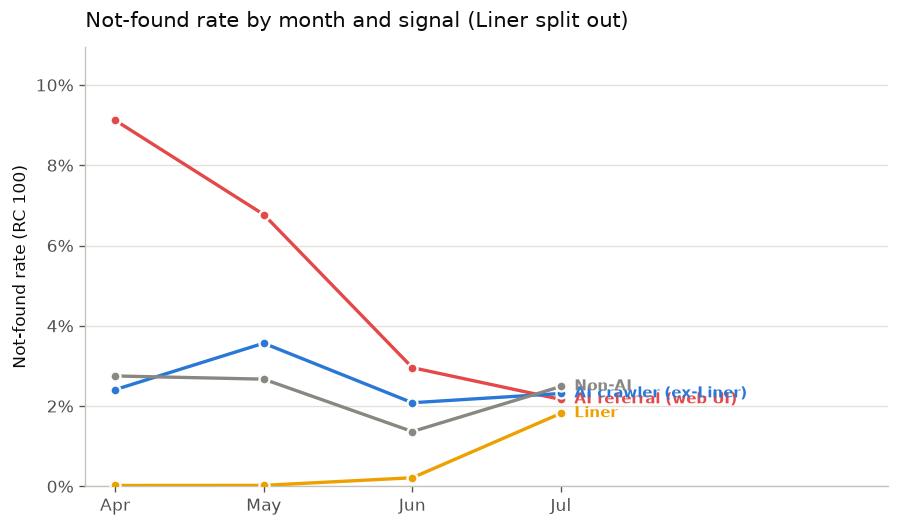

In [7]:
sm = (df.groupby(["month","label"], as_index=False)
        .agg(ref_ev=("ref_ev","sum"), ref_nf=("ref_nf","sum"),
             exl_ev=("exl_ev","sum"), exl_nf=("exl_nf","sum"),
             liner_ev=("liner_ev","sum"), liner_nf=("liner_nf","sum"),
             non_ev=("non_ev","sum"), non_nf=("non_nf","sum")).sort_values("month"))
sm["AI referral (web UI)"]    = 100*sm["ref_nf"]/sm["ref_ev"]
sm["AI crawler (ex-Liner)"]   = 100*sm["exl_nf"]/sm["exl_ev"]
sm["Liner"]                   = 100*sm["liner_nf"]/sm["liner_ev"]
sm["Non-AI"]                  = 100*sm["non_nf"]/sm["non_ev"]

series = [("AI referral (web UI)", C_REF), ("AI crawler (ex-Liner)", C_UA),
          ("Non-AI", C_BASE), ("Liner", C_LINER)]
fig, ax = plt.subplots(figsize=(7.6, 4.5))
x = np.arange(len(sm))
for name, color in series:
    y = sm[name].values
    ax.plot(x, y, color=color, lw=2, marker="o", ms=6,
            markerfacecolor=color, markeredgecolor="#fcfcfb", markeredgewidth=1.4, zorder=3)
    ax.annotate(name, (x[-1], y[-1]), textcoords="offset points", xytext=(8,0),
                va="center", ha="left", fontsize=9.0, color=color, fontweight="bold")
ax.set_xticks(x); ax.set_xticklabels(sm["label"])
ax.set_xlim(-0.2, len(sm)+1.2)
ax.set_ylabel("Not-found rate (RC 100)")
ax.set_ylim(0, sm[[s for s,_ in series]].values.max()*1.2)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))
ax.set_title("Not-found rate by month and signal (Liner split out)", loc="left", fontsize=12.5, pad=12)
ax.grid(axis="x", visible=False)
fig.tight_layout(); plt.show()

## Part 3 — Which sources surface the most non-existent DOIs?

Every AI source (referrer tools **and** crawler user-agents), ranked by
not-found rate. Sources with fewer than **3,000** events are dropped as noisy;
bars are colored by signal. The dashed line is the non-AI baseline.

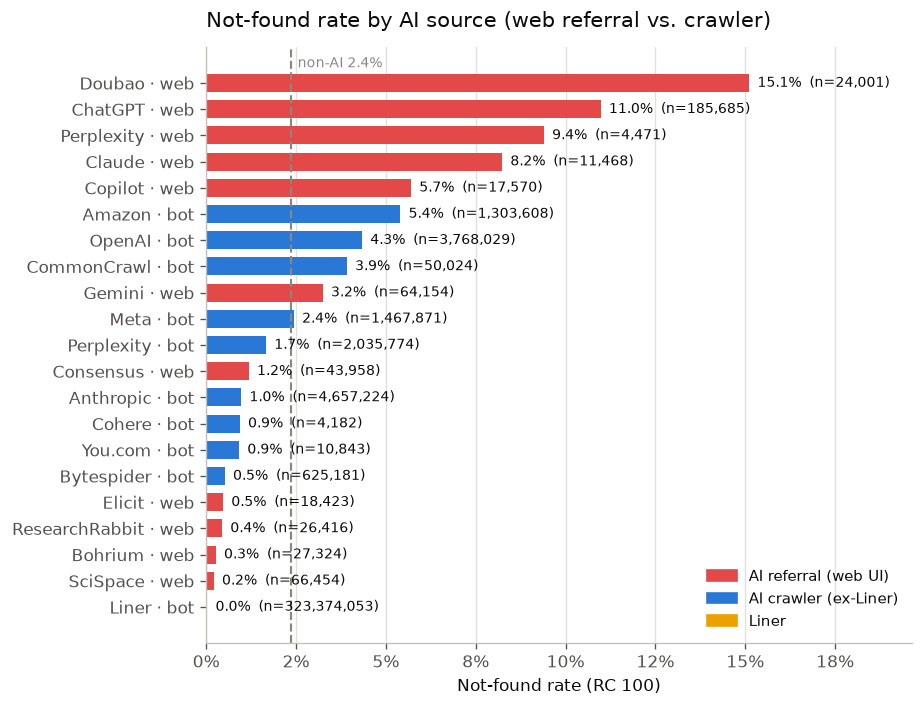

,source,total,not_found,nf_rate
20,Liner · bot,323374053,89907,0.03
11,SciSpace · web,66454,138,0.21
0,Bohrium · web,27324,72,0.26
10,ResearchRabbit · web,26416,116,0.44
6,Elicit · web,18423,86,0.47
16,Bytespider · bot,625181,3218,0.51
24,You.com · bot,10843,99,0.91
17,Cohere · bot,4182,39,0.93
14,Anthropic · bot,4657224,45229,0.97
3,Consensus · web,43958,520,1.18


In [8]:
def source_frame(flag, col, tag, signal):
    s = (df[df[flag]].groupby(col, as_index=False)
           .agg(total=("total","sum"), not_found=("not_found","sum")))
    s["source"] = s[col] + tag
    s["signal"] = signal
    return s[["source","signal","total","not_found"]]

src = pd.concat([
    source_frame("ref_ai", "ref_tool", " · web", "AI referral (web UI)"),
    source_frame("ua_ai",  "ua_bot",   " · bot", "AI crawler (user-agent)"),
], ignore_index=True)
src["nf_rate"] = 100*src["not_found"]/src["total"]
src = src[src["total"] >= 3000].sort_values("nf_rate")
def src_color(row):
    if row["source"].startswith("Liner"): return C_LINER
    return C_REF if row["signal"] == "AI referral (web UI)" else C_UA
colors = src.apply(src_color, axis=1)

fig, ax = plt.subplots(figsize=(7.8, 6.0))
bars = ax.barh(src["source"], src["nf_rate"], color=colors, height=0.68)
for bar, r, t in zip(bars, src["nf_rate"], src["total"]):
    ax.annotate(f"{r:.1f}%  (n={t:,})", (bar.get_width(), bar.get_y()+bar.get_height()/2),
                textcoords="offset points", xytext=(5,0), va="center", fontsize=8.5, color=INK)
ax.axvline(non_r, color=C_BASE, lw=1.3, ls="--", zorder=1)
ax.annotate(f"non-AI {non_r:.1f}%", (non_r, len(src)-0.4), textcoords="offset points",
            xytext=(4,0), fontsize=8.5, color=C_BASE)
ax.set_xlabel("Not-found rate (RC 100)")
ax.set_xlim(0, src["nf_rate"].max()*1.30)
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))
ax.set_title("Not-found rate by AI source (web referral vs. crawler)",
             loc="left", fontsize=12.5, pad=12)
ax.grid(axis="y", visible=False)
ax.legend(handles=[Patch(color=C_REF, label="AI referral (web UI)"),
                   Patch(color=C_UA, label="AI crawler (ex-Liner)"),
                   Patch(color=C_LINER, label="Liner")],
          frameon=False, fontsize=9, loc="lower right")
fig.tight_layout(); plt.show()
src.assign(nf_rate=src["nf_rate"].round(2))[["source","total","not_found","nf_rate"]]

### Per-source monthly trend

Not-found rate over the quarter for the highest-volume AI sources, as small
multiples on a shared axis (dashed line = non-AI baseline).

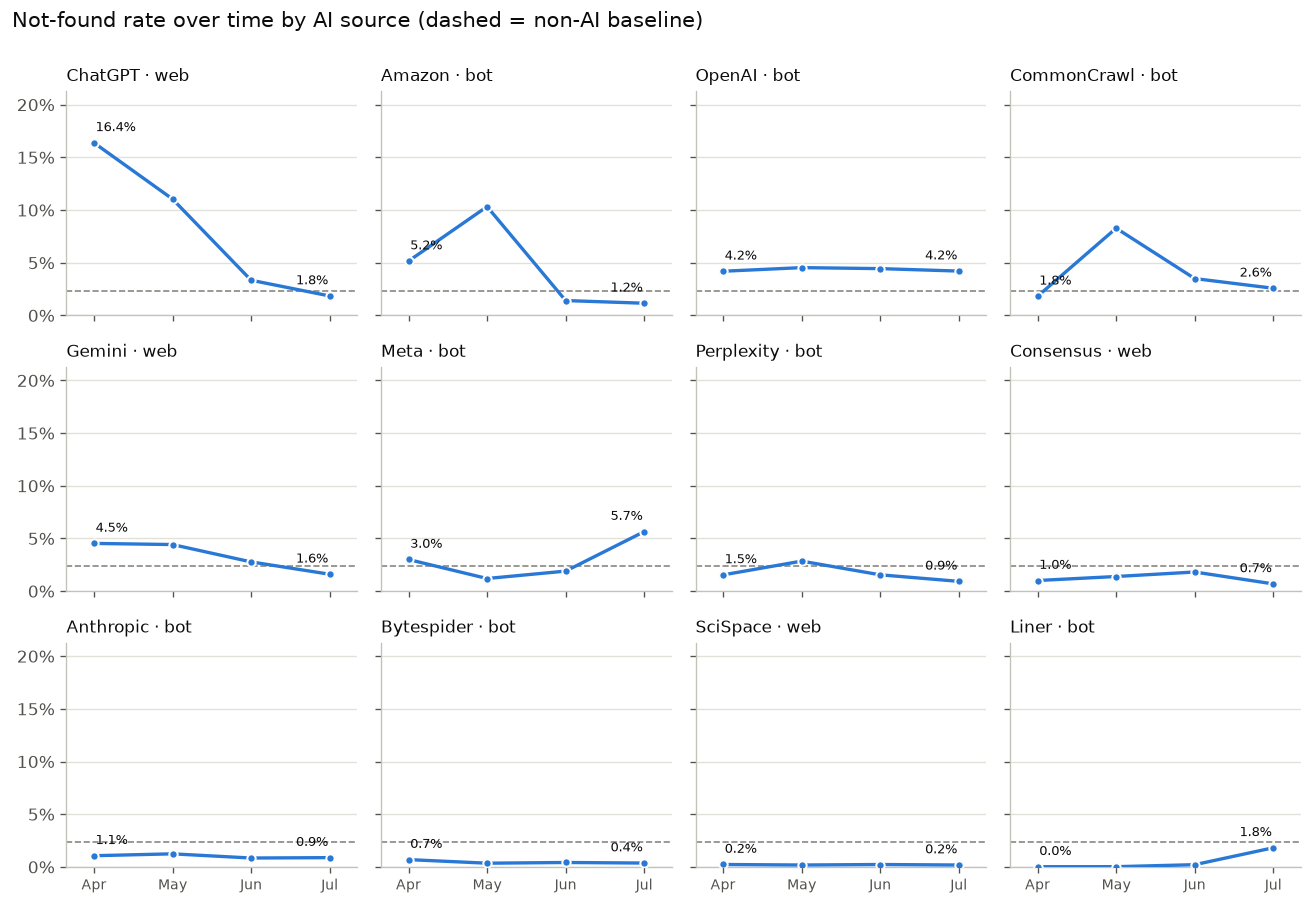

In [9]:
def source_month(flag, col, tag):
    s = (df[df[flag]].groupby([col,"month","label"], as_index=False)
           .agg(total=("total","sum"), nf=("not_found","sum")))
    s["source"] = s[col] + tag
    return s[["source","month","label","total","nf"]]

srcm = pd.concat([source_month("ref_ai","ref_tool"," · web"),
                  source_month("ua_ai","ua_bot"," · bot")], ignore_index=True)
srcm["nf_rate"] = 100*srcm["nf"]/srcm["total"]

top = (src.sort_values("total", ascending=False)["source"].head(12).tolist())
order = (src[src["source"].isin(top)].sort_values("nf_rate", ascending=False)["source"].tolist())

ncols = 4; nrows = -(-len(order)//ncols)
ymax = srcm[srcm.source.isin(order)]["nf_rate"].max()*1.30
fig, axes = plt.subplots(nrows, ncols, figsize=(11, 2.5*nrows), sharex=True, sharey=True)
axf = axes.flat
for i, s in enumerate(order):
    ax = axf[i]; d = srcm[srcm.source == s].sort_values("month"); xs = range(len(d))
    ax.axhline(non_r, color=C_BASE, lw=1, ls="--", zorder=1)
    ax.plot(xs, d["nf_rate"], color=BLUE, lw=2, marker="o", ms=5,
            markerfacecolor=BLUE, markeredgecolor="#fcfcfb", markeredgewidth=1.2, zorder=3)
    for j, ha, dx in ((0,"left",1),(len(d)-1,"right",-1)):
        ax.annotate(f"{d['nf_rate'].iloc[j]:.1f}%", (j, d["nf_rate"].iloc[j]),
                    textcoords="offset points", xytext=(dx,7), ha=ha, fontsize=8, color=INK)
    ax.set_title(s, fontsize=10, loc="left", color=INK)
    ax.set_xticks(list(xs)); ax.set_xticklabels(d["label"], fontsize=8.5)
    ax.set_xlim(-0.35, len(d)-0.65); ax.set_ylim(0, ymax)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))
    ax.grid(axis="x", visible=False)
for j in range(len(order), nrows*ncols):
    axf[j].axis("off")
fig.suptitle("Not-found rate over time by AI source (dashed = non-AI baseline)",
             x=0.01, ha="left", fontsize=12.5, y=1.0)
fig.tight_layout(); plt.show()

## Findings

Because one crawler (**Liner** / `LinerBot`, getliner.com) is ~19% of *all*
DataCite traffic across these four months, it is broken out as its own category
throughout. That leaves four clean buckets: **Liner**, **AI crawler (ex-Liner)**,
**AI referral (web UI)**, and **Non-AI**.

1. **Liner crawled hard, then vanished.** It went **~37.0% of April traffic →
   17.7% (May) → 3.1% (June) → ~0% (July, just 934 events)** — a single
   aggressive backfill that shut off entirely. Over the full period it is ~19%
   of all resolutions (~323M events), but it is now effectively gone.

2. **AI drives ~20% of resolutions over the period — and almost all of that is
   Liner.** Excluding Liner, all other AI activity is ~0.8% of traffic: ~13.9M
   crawler events plus a ~0.49M (~0.03%) sliver of human web-UI referrals. The
   referral and crawler signals barely overlap.

3. **Not-found rate cleanly separates the four buckets** (baseline = non-AI ~2.4%):
   - **AI referral (web UI): ~6.0% (~2.5× baseline)** — humans following
     hallucinated/mistyped DOIs; the strongest error signal.
   - **AI crawler ex-Liner: ~2.5% (~1.1×)** — modestly above baseline.
   - **Liner: ~0.03% (~0.01×)** — a systematic crawler hitting almost only real
     DOIs; it is what dragged the un-split crawler average down and lifted the
     non-AI baseline (its clean hits would otherwise count as non-AI).

4. **By source:** among web-UI referrals, general assistants (ChatGPT, Doubao,
   Claude, Perplexity) dominate the failures while research tools stay low; among
   crawlers, Amazon and OpenAI stand out, Anthropic and Bytespider sit low, and
   Liner is near zero.

**Caveats.** Both signals undercount AI (agents that spoof a browser UA and drop
the referrer are invisible). Per-source rates for low-volume sources are noisy
(min-volume filter applied). RC `100` = non-existent handle; it does not separate
a hallucinated DOI from a typo or a deleted record.

In [10]:
print(f"AI share (both signals)  : {100*ai_t/tot:.2f}%   (Liner {100*liner_t/tot:.2f}% + ex-Liner {100*(ai_t-liner_t)/tot:.3f}%)")
print(f"Not-found — web referral : {ref_r:.2f}%  ({ref_r/non_r:.1f}x baseline)")
print(f"Not-found — crawler(exL) : {exl_r:.2f}%  ({exl_r/non_r:.1f}x baseline)")
print(f"Not-found — Liner        : {liner_r:.2f}%  ({liner_r/non_r:.2f}x baseline)")
print(f"Not-found — non-AI       : {non_r:.2f}%")

AI share (both signals)  : 19.98%   (Liner 19.13% + ex-Liner 0.853%)
Not-found — web referral : 6.00%  (2.5x baseline)
Not-found — crawler(exL) : 2.54%  (1.1x baseline)
Not-found — Liner        : 0.03%  (0.01x baseline)
Not-found — non-AI       : 2.36%
